# Static linear encoding and Information Imbalance

This notebook combines bidirectional static linear encoding with Information Imbalance (II) at one neural-response timepoint. It performs the following operations:

1. Predict model features from the selected neural population response (`neural -> model`).
2. Predict the neural population response from model features (`model -> neural`).
3. Compute per-output $R^2$ for both projections.
4. Compute static II between the **predicted neural** and **predicted model** spaces.

By default, the projections are fitted and evaluated on all images (`use_cv=False`). Setting `use_cv=True` produces out-of-fold predictions, and II is then computed only from those out-of-fold predictions.

In [125]:
import os
import sys
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from sklearn.decomposition import PCA
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor
import math

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

# from II_analyses.static_encoding import (
#     compute_static_prediction_II,
#     fit_static_projection,
# )
from project_specific_utils.dataloader import (
    load_img_natraster,
    map_image_order_from_ann_to_monkey,
)
from IT_recap.hf_feature_extraction import (
    ProcessorTransform,
    is_valid_image_file,
    load_hf_layer_features,
)
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.image_processing.computational_models import imgANN


In [126]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    new_fs: int = 100
    # pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "dino_v3_l"
    model_source: str = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    img_size: int = 224
    use_fast_processor: bool = True
    pkg = "hf"
    layer_names: list[str] = field(default_factory=lambda: [
        "layer.3.mlp.down_proj",
        "layer.13.mlp.down_proj",
        "layer.20.mlp.down_proj",
    ])
    pooling: str = "mean"
    trust_remote_code = True
    attn_implementation = "sdpa"
    training_input_mode: str = "activations"  # "images" or "activations"

    batch_size = 64
    validation_fraction: float = 0.2
    random_seed: int = 0
    epochs: int = 100
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    temporal_embedding_dim: int = 64
    value_dim: int = 32
    temporal_compression_ratio: int = 3
    mlp_hidden_dim: int = 128
    # linear_regression_alpha: float = 1e-2
    
# EOC


cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', new_fs=100, model_name='dino_v3_l', model_source='facebook/dinov3-vitl16-pretrain-lvd1689m', img_size=224, use_fast_processor=True, layer_names=['layer.3.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.20.mlp.down_proj'], pooling='mean', training_input_mode='activations', validation_fraction=0.2, random_seed=0, epochs=100, learning_rate=0.0001, weight_decay=0.0001, temporal_embedding_dim=64, value_dim=32, temporal_compression_ratio=3, mlp_hidden_dim=128)

## Load and align the static spaces

The neural raster is shaped `(neurons, timepoints, images)`, while cached DINO features are shaped `(images, layers, embedding)`. Images and activations remain in their shared ImageFolder source order; `NeuralInputDataset` applies `idx_ord` to either source when pairing it with neural occurrence order.

In [127]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

# Load the preprocessing recipe saved with the Hugging Face checkpoint.
image_processor = AutoImageProcessor.from_pretrained(
    cfg.model_source,
    use_fast=cfg.use_fast_processor,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    transform=ProcessorTransform(image_processor),
    is_valid_file=is_valid_image_file,
    allow_empty=True,
)

# Fail early if the checkpoint processor and configured model size disagree.
sample_image, _ = dataset[0]
sample_shape = tuple(sample_image.shape[-2:])
if sample_shape != (cfg.img_size, cfg.img_size):
    raise ValueError(
        f"Processor returned {sample_shape}, expected "
        f"{(cfg.img_size, cfg.img_size)}."
    )
# end if processor output size differs from model input size
idx_ord = map_image_order_from_ann_to_monkey(
    paths, cfg.monkey_name, cfg.date, dataset
)

raster_array = raster.get_array()

if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, images), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3

# Load frozen DINO outputs in their original ImageFolder order.
# NeuralInputDataset applies idx_ord to images or activations exactly once.
precomputed_layer_features = load_hf_layer_features(
    output_dir=Path(paths["data_path"]) / "models",
    dataset_name=cfg.folder_name,
    model_name=cfg.model_name,
    img_size=cfg.img_size,
    layer_names=cfg.layer_names,
    pooling=cfg.pooling,
)
if precomputed_layer_features.shape[0] != len(dataset):
    raise ValueError(
        "Cached features and ImageFolder have different image counts: "
        f"{precomputed_layer_features.shape[0]} and {len(dataset)}."
    )
# end if cached features and ImageFolder are misaligned

print(f"Neural raster: {raster_array.shape}")
print(f"Cached DINO features: {precomputed_layer_features.shape}")


Neural raster: (25, 30, 776)
Cached DINO features: (776, 3, 1024)


In [128]:
class NeuralInputDataset(Dataset):
    """Pair neural responses with images or cached DINO activations."""

    def __init__(
        self,
        image_dataset,
        activations,
        neural_activity,
        image_indices,
        input_mode,
    ):
        if input_mode not in {"images", "activations"}:
            raise ValueError(
                "input_mode must be either 'images' or 'activations'."
            )
        # end if input mode is invalid

        # image_indices maps neural-order positions to source-order positions.
        self.input_mode = input_mode
        neural_activity = np.asarray(neural_activity)
        self.image_indices = np.asarray(image_indices, dtype=int)
        if neural_activity.ndim != 3:
            raise ValueError(
                "neural_activity must have shape [neurons, time, images]."
            )
        # end if neural activity has the wrong shape
        if self.image_indices.ndim != 1:
            raise ValueError("image_indices must be one-dimensional.")
        # end if image indices have the wrong shape
        if len(self.image_indices) != neural_activity.shape[2]:
            raise ValueError(
                f"Found {len(self.image_indices)} mapped stimuli but "
                f"{neural_activity.shape[2]} neural responses."
            )
        # end if mapped stimuli and neural responses differ
        if self.image_indices.size == 0:
            raise ValueError("image_indices must not be empty.")
        # end if no image indices were provided
        indices_are_invalid = (
            self.image_indices.min() < 0
            or self.image_indices.max() >= len(image_dataset)
        )
        if indices_are_invalid:
            raise IndexError("image_indices exceed the ImageFolder dataset.")
        # end if an image index is out of bounds

        self.image_dataset = image_dataset
        self.activations = None
        if activations is not None:
            activations = np.asarray(activations)
            if activations.ndim != 3:
                raise ValueError(
                    "Expected activations with shape "
                    "[images, layers, embedding], got "
                    f"{activations.shape}."
                )
            # end if activations have the wrong shape
            if len(image_dataset) != activations.shape[0]:
                raise ValueError(
                    f"Found {len(image_dataset)} images but "
                    f"{activations.shape[0]} activation rows."
                )
            # end if images and activations have different source counts
            self.activations = torch.as_tensor(
                activations,
                dtype=torch.float32,
            )
        # end if activations were provided
        if self.input_mode == "activations" and self.activations is None:
            raise ValueError(
                "activations are required when input_mode='activations'."
            )
        # end if activation mode was requested without activations

        # Targets already follow neural occurrence order: [images, time, neurons].
        self.neural_activity = torch.as_tensor(
            neural_activity.transpose(2, 1, 0),
            dtype=torch.float32,
        )

    def __len__(self):
        return len(self.neural_activity)
    # EOF

    def __getitem__(self, index):
        # Apply the same neural-to-source mapping to either input modality.
        source_index = self.image_indices[index]
        if self.input_mode == "images":
            model_input, _ = self.image_dataset[source_index]
        else:
            model_input = self.activations[source_index]
        # end if images are requested
        target = self.neural_activity[index]  # [time, neurons]
        return model_input, target
    # EOF
# EOC


In [129]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.img_size,
    pooling=cfg.pooling,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.model_source,
    trust_remote_code=cfg.trust_remote_code,
)

18:22:21 - device being used: mps


In [130]:
"""
make_neural_input_loader
Build an aligned loader that returns images or cached DINO activations.

INPUT:
    - input_mode: str -> either "images" or "activations"
    - image_dataset: Dataset -> ImageFolder in its original source order
    - activations: np.ndarray | None -> cached [images, layers, embedding]
    - neural_activity: np.ndarray -> responses [neurons, time, images]
    - image_indices: array-like -> neural-order to source-order mapping
    - batch_size: int -> samples per batch
    - shuffle: bool -> whether to shuffle aligned input-target pairs
    - pin_memory: bool -> whether DataLoader pins CPU tensors

OUTPUT:
    - loader: DataLoader -> aligned model-input and neural-target batches
"""
def make_neural_input_loader(
    input_mode,
    image_dataset,
    activations,
    neural_activity,
    image_indices,
    batch_size,
    shuffle,
    pin_memory,
):
    paired_dataset = NeuralInputDataset(
        image_dataset=image_dataset,
        activations=activations,
        neural_activity=neural_activity,
        image_indices=image_indices,
        input_mode=input_mode,
    )
    return DataLoader(
        paired_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=pin_memory,
    )
# EOF


# Change cfg.training_input_mode to switch the training input source.
loader = make_neural_input_loader(
    input_mode=cfg.training_input_mode,
    image_dataset=dataset,
    activations=precomputed_layer_features,
    neural_activity=raster_array,
    image_indices=idx_ord,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=torch.device(ann.get_device()).type == "cuda",
)


# TODO 
1. import and load imgANN
2. make the forward pass work and comment that tidily
3. add R^2 evaluation for the fitted population predictions
4. make the training loop

In [131]:
class BaselineModel(torch.nn.Module):
    def __init__(
            self, 
            encoder, 
            layers, 
            temporal_embedding_dim, 
            value_dim, 
            n_timepoints, 
            temporal_compression_ratio, 
            n_neurons,
            mlp_hidden_dim,
            key_query_dim=None
            ):    
        super(BaselineModel, self).__init__()
        self.layer_names = list(layers)
        self.n_layers = len(self.layer_names)

        # set up the encoder
        encoder.model.eval()
        self.encoder = encoder
        for parameter in self.encoder.model.parameters():
            parameter.requires_grad_(False)
        # end for parameter

        self.encoder.set_relevant_layers(layers)
        self.encoder_dim = self.encoder.get_layer_output_shape(layers[0])[1] # assumes all layers to have the same embedding dimension (Visual transformer case)
        self.encoder.create_forward_hook() # it's taking the relevant layers we've set

        # Register the underlying nn.Module as a real submodule so that
        # BaselineModel.to(device)/.parameters()/.state_dict() see its weights too.
        # `imgANN` itself is a plain wrapper (not an nn.Module), so assigning it to
        # self.encoder above does NOT register it - self.encoder.model IS the same
        # nn.Module object, so hooks registered on it by create_forward_hook() keep
        # working regardless of which attribute we reach it through.
        self.encoder_backbone = self.encoder.model

        # set up temporal embeddings
        # Learned coarse temporal queries:
        # (T_te, E_te)
        if n_timepoints % temporal_compression_ratio != 0:
            raise ValueError(
                "n_timepoints must be divisible by temporal_compression_ratio."
            )
        # end if temporal dimensions do not divide evenly
        self.temporal_compression_ratio = temporal_compression_ratio
        self.n_temporal_embeddings = (
            n_timepoints // temporal_compression_ratio
        )
        self.n_timepoints = n_timepoints
        self.n_neurons = n_neurons
        self.temporal_embedding_dim = temporal_embedding_dim
        self.temporal_embeddings = nn.Parameter(
            torch.randn(
                self.n_temporal_embeddings,
                self.temporal_embedding_dim
            )
            * 0.02
        ) # TODO check out how to initialize

        # set up attention dimensions
        if key_query_dim is not None:
            self.key_dim = key_query_dim
            self.query_dim = key_query_dim
        else:
            self.key_dim = self.temporal_embedding_dim
            self.query_dim = self.temporal_embedding_dim
        # end if key_query_dim is not None:
        self.value_dim = value_dim

        # Backbone layer features -> keys
        # (B, L, E_in) -> (B, L, E_k)
        self.key_projection = nn.Linear(
            self.encoder_dim,
            self.key_dim,
            bias=False,
        )
        # Backbone layer features -> values
        # (B, L, E_in) -> (B, L, E_v)
        self.value_projection = nn.Linear(
            self.encoder_dim,
            self.value_dim,
            bias=False,
        )
        if self.query_dim != self.temporal_embedding_dim:
            self.query_projection = nn.Linear(
                self.temporal_embedding_dim,
                self.value_dim,
                bias=False,
            )
            
        # normalization of projected layer features
        self.key_norm = nn.LayerNorm(self.key_dim)
        self.value_norm = nn.LayerNorm(self.value_dim)

        # Expand every coarse value embedding into a non-overlapping block
        # of fine-time value embeddings. The MLP reads only E_v, so coarse
        # temporal points remain independent:
        # (B, T_te, E_v) -> (B, T_te, temporal_compression_ratio * E_v).
        self.temporal_upsampling_mlp = nn.Sequential(
            nn.Linear(value_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(
                mlp_hidden_dim,
                temporal_compression_ratio * value_dim,
            ),
        )

        # Map each fine-time value embedding independently to N neurons:
        # (B, T, E_v) -> (B, T, N).
        self.neural_prediction_mlp = nn.Sequential(
            nn.Linear(value_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, n_neurons),
        )

    def train(self, mode=True):
        # Keep the frozen backbone pinned in eval mode regardless of the outer
        # model's mode (now that encoder_backbone is a registered submodule, a
        # plain super().train() call would otherwise re-enable its dropout).
        super().train(mode)
        self.encoder_backbone.eval()
        return self
    # EOF

    @property
    def device(self):
        # Derived from a live parameter rather than the imgANN.device attribute,
        # which stays stale after BaselineModel.to(device) moves the weights.
        return next(self.parameters()).device
    # EOF

    # --- GETTERS ---
    def get_encoder(self):
        return self.encoder

    def get_layer_names(self) -> list[str]:
        return self.layer_names

    def get_encoder_dim(self) -> int:
        return self.encoder_dim

    def get_temporal_embedding_dim(self) -> int:
        return self.temporal_embedding_dim

    def get_n_temporal_embeddings(self) -> int:
        return self.temporal_embeddings.shape[0]

    def get_temporal_compression_ratio(self) -> int:
        return self.temporal_compression_ratio

    def get_n_timepoints(self) -> int:
        return self.n_timepoints

    def get_n_neurons(self) -> int:
        return self.n_neurons

    def get_key_dim(self) -> int:
        return self.key_dim

    def get_query_dim(self) -> int:
        return self.query_dim

    def get_value_dim(self) -> int:
        return self.value_dim

    def get_trainable_parameters(self):
        return (p for p in self.parameters() if p.requires_grad)

    def get_trainable_named_parameters(self):
        return ((name, p) for name, p in self.named_parameters() if p.requires_grad)
    # EOF

    """
    _resolve_layer_features
    Select cached layer features or extract them online with frozen DINO.

    INPUT:
        - x: torch.Tensor -> images or cached features
        - use_precomputed_features: bool -> whether x is [B, L, E_in]

    OUTPUT:
        - layer_features: torch.Tensor -> features [B, L, E_in]
    """
    def _resolve_layer_features(self, x, use_precomputed_features):
        if use_precomputed_features:
            # Training can bypass DINO when its frozen outputs are cached.
            layer_features = x
        else:
            # This remains the default path for inference on unseen images.
            with torch.no_grad():
                self.encoder.model(x)
            # end with frozen encoder forward
            captured_features = self.encoder.features
            layer_features = torch.stack(
                [captured_features[layer] for layer in self.layer_names],
                dim=1,
            )
        # end if precomputed features are supplied

        expected_shape = (self.n_layers, self.encoder_dim)
        has_expected_shape = (
            layer_features.ndim == 3
            and tuple(layer_features.shape[1:]) == expected_shape
        )
        if not has_expected_shape:
            raise ValueError(
                "Expected layer features with shape [batch, layers, embedding] "
                f"and trailing dimensions {expected_shape}, got "
                f"{tuple(layer_features.shape)}."
            )
        # end if layer features have the wrong shape

        # Cached CPU arrays follow the trainable projection's device and dtype.
        return layer_features.to(
            device=self.key_projection.weight.device,
            dtype=self.key_projection.weight.dtype,
        )
    # EOF

    def forward(self, x, use_precomputed_features=False):
        # 1. Resolve one pooled feature vector per selected DINO layer.
        #
        # layer_features: (B, L, E_in)
        #
        # B    = batch size
        # L    = number of selected layers, e.g. 3
        # E_in = original backbone embedding dimension
        layer_features = self._resolve_layer_features(
            x,
            use_precomputed_features,
        )
        # print("layer features", layer_features.shape)

        # 2. Project layer features into keys and values
        #
        # K = key_projection(layer_features)
        # V = value_projection(layer_features)
        #
        # K: (B, L, E_k)
        # V: (B, L, E_v)
        # Layer features become keys and values
        keys = self.key_projection(layer_features)
        keys = self.key_norm(keys)
        # print("keys", keys.shape)
        values = self.value_projection(layer_features)
        values = self.value_norm(values)
        # print("values", values.shape)

        # 3. Create/project temporal embeddings into queries
        #
        # temporal_embeddings: (T_te, E_te)
        # Q = query_projection(temporal_embeddings)
        #
        # Q: (T_te, E_k)
        #
        # expand over batch:
        # Q: (B, T_te, E_k)
        if hasattr(self, "query_projection"):
            queries = self.query_projection(self.temporal_embeddings)
        else:
            queries = self.temporal_embeddings
        # end if hasattr(self, "query_projection"):
        # Expand over batch
        queries = queries.unsqueeze(0).expand(layer_features.shape[0], -1, -1) # TODO find a more elegant way to define B
        # print("queries", queries.shape)

        # 4. Compute cross-attention over encoder layers independently at each coarse timepoint
        #
        # attention_logits = Q @ K.transpose(-1, -2) / sqrt(E_k)
        #
        # Q:                (B, T_te, E_k)
        # K.transpose:      (B, E_k, L)
        # attention_logits: (B, T_te, L)
        attention_logits = torch.matmul(
            queries,
            keys.transpose(-1, -2),
        )
        # print("attention logits: ", attention_logits.shape)
        attention_logits = attention_logits / math.sqrt(self.key_dim) # Q K.T/sqrt(d)

        # Softmax across L gives one layer-attention map per coarse timepoint.
        # attention_weights: (B, T_te, L)
        attention_weights = torch.softmax(
            attention_logits,
            dim=-1,
        )

        # Combine the projected layer values independently at each timepoint.
        # coarse_latents = attention_weights @ V
        # (B, T_te, L) @ (B, L, E_v) -> (B, T_te, E_v)
        coarse_latents = torch.matmul(
            attention_weights,
            values,
        )
        # 5. Expand coarse latents into fine-time value embeddings.
        # (B, T_te, E_v) -> (B, T_te, compression_ratio * E_v)
        fine_latent_blocks = self.temporal_upsampling_mlp(coarse_latents)

        # Split each block along time, then concatenate the non-overlapping
        # blocks in temporal order: (B, T_te, R, E_v) -> (B, T, E_v).
        fine_latent_blocks = fine_latent_blocks.reshape(
            fine_latent_blocks.shape[0],
            self.n_temporal_embeddings,
            self.temporal_compression_ratio,
            self.value_dim,
        )
        fine_latents = fine_latent_blocks.reshape(
            fine_latent_blocks.shape[0],
            self.n_timepoints,
            self.value_dim,
        )

        # 6. Predict N neurons independently at every fine time point.
        # (B, T, E_v) -> (B, T, N)
        neural_predictions = self.neural_prediction_mlp(fine_latents)

        return neural_predictions, attention_weights
        
        

In [132]:
m = BaselineModel(
    encoder=ann,
    layers=cfg.layer_names,
    temporal_embedding_dim=cfg.temporal_embedding_dim,
    value_dim=cfg.value_dim,
    n_timepoints=raster_array.shape[1],
    temporal_compression_ratio=cfg.temporal_compression_ratio,
    n_neurons=raster_array.shape[0],
    mlp_hidden_dim=cfg.mlp_hidden_dim,
).to(ann.device)


In [133]:
use_precomputed_features = loader.dataset.input_mode == "activations"

for model_input, neu in loader:
    model_input = model_input.to(m.device)
    neu = neu.to(m.device)
    a = m(
        model_input,
        use_precomputed_features=use_precomputed_features,
    )
    break

# At inference, m(images) uses DINO because use_precomputed_features defaults to False.

In [134]:
a[0].shape

torch.Size([64, 30, 25])

## Neural-activity prediction loss

The population loss is mean-squared error over batch, time, and neurons:

$$\mathcal{L}_{\mathrm{MSE}} = \frac{1}{BTN} \sum_{b,t,n} (\hat{y}_{btn} - y_{btn})^2.$$

In [135]:
"""
neural_activity_mse_loss
Compute population MSE between predicted and recorded neural activity.

INPUT:
    - predictions: torch.Tensor -> predicted activity [batch, time, neurons]
    - targets: torch.Tensor -> recorded activity [batch, time, neurons]

OUTPUT:
    - loss: torch.Tensor -> scalar mean-squared error
"""
def neural_activity_mse_loss(predictions, targets):
    if predictions.ndim != 3 or targets.ndim != 3:
        raise ValueError(
            "Predictions and targets must both have shape [batch, time, neurons]."
        )
    # end if either neural tensor does not have three axes
    if predictions.shape != targets.shape:
        raise ValueError(
            f"Prediction shape {predictions.shape} does not match "
            f"target shape {targets.shape}."
        )
    # end if predictions and targets are misaligned
    return nn.functional.mse_loss(predictions, targets)
# EOF

# Training and online validation
## training (repeat for the whole training set -> 1 epoch)
1. Pass minibatch
2. compute loss
3. backpropagate
4. do the optimizer step
5. zero the gradient
6. accumulate the sample-weighted training loss

## testing (repeat for the whole validation set at every epoch)
1. switch the network to evaluation mode
2. compute the loss
3. accumulate the sample-weighted validation loss


In [136]:
"""
training_step
Train the neural regression model for one complete epoch.

INPUT:
    - net: nn.Module -> neural prediction model
    - data_loader: DataLoader -> training inputs and neural targets
    - optimizer: torch.optim.Optimizer -> parameter optimizer
    - cost_function: callable -> scalar neural regression loss
    - use_precomputed_features: bool -> whether inputs bypass DINO
    - device: torch.device | str -> training device

OUTPUT:
    - mean_loss: float -> sample-weighted training MSE
"""
def training_step(
    net,
    data_loader,
    optimizer,
    cost_function,
    use_precomputed_features,
    device="cpu",
):
    samples = 0
    cumulative_loss = 0.0

    # Set the network to training mode. BaselineModel keeps DINO in eval mode.
    net.train()

    # Iterate once over the complete training set.
    for inputs, targets in data_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Forward pass and neural population loss.
        predictions, _ = net(
            inputs,
            use_precomputed_features=use_precomputed_features,
        )
        loss = cost_function(predictions, targets)

        # Backpropagate, update trainable parameters, then reset gradients.
        loss.backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        # Weight the batch mean by its sample count before epoch averaging.
        batch_samples = inputs.shape[0]
        samples += batch_samples
        cumulative_loss += loss.item() * batch_samples
    # end for training batch

    return cumulative_loss / samples
# EOF


"""
test_step
Evaluate neural regression loss over the complete validation set.

INPUT:
    - net: nn.Module -> neural prediction model
    - data_loader: DataLoader -> validation inputs and neural targets
    - cost_function: callable -> scalar neural regression loss
    - use_precomputed_features: bool -> whether inputs bypass DINO
    - device: torch.device | str -> evaluation device

OUTPUT:
    - mean_loss: float -> sample-weighted validation MSE
"""
def test_step(
    net,
    data_loader,
    cost_function,
    use_precomputed_features,
    device="cpu",
):
    samples = 0
    cumulative_loss = 0.0

    # Switch the network to evaluation mode for validation.
    net.eval()

    # Validation must not build gradients or update model parameters.
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            predictions, _ = net(
                inputs,
                use_precomputed_features=use_precomputed_features,
            )
            loss = cost_function(predictions, targets)

            batch_samples = inputs.shape[0]
            samples += batch_samples
            cumulative_loss += loss.item() * batch_samples
        # end for validation batch
    # end with no gradient tracking

    return cumulative_loss / samples
# EOF

In [137]:
if not 0.0 < cfg.validation_fraction < 1.0:
    raise ValueError("validation_fraction must be between zero and one.")
# end if validation fraction is invalid

# Split whole stimuli so no image appears in both training and validation.
full_dataset = loader.dataset
n_validation = max(1, round(len(full_dataset) * cfg.validation_fraction))
n_training = len(full_dataset) - n_validation
if n_training == 0:
    raise ValueError("The validation split leaves no training samples.")
# end if training split is empty

split_generator = torch.Generator().manual_seed(cfg.random_seed)
training_dataset, validation_dataset = random_split(
    full_dataset,
    [n_training, n_validation],
    generator=split_generator,
)
pin_memory = torch.device(m.device).type == "cuda"
training_loader = DataLoader(
    training_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    pin_memory=pin_memory,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    pin_memory=pin_memory,
)

# Configure regression optimization over trainable parameters only.
optimizer = torch.optim.AdamW(
    m.get_trainable_parameters(),
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)
cost_function = neural_activity_mse_loss
use_precomputed_features = full_dataset.input_mode == "activations"
optimizer.zero_grad(set_to_none=True)

# Evaluate the randomly initialized trainable model before any update.
initial_validation_loss = test_step(
    m,
    validation_loader,
    cost_function,
    use_precomputed_features,
    device=m.device,
)
print(f"epoch 000/{cfg.epochs:03d} | validation {initial_validation_loss:.6f}")

# Run one validation pass after every complete training epoch.
training_losses = []
validation_losses = []
for epoch in range(1, cfg.epochs + 1):
    training_loss = training_step(
        m,
        training_loader,
        optimizer,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    validation_loss = test_step(
        m,
        validation_loader,
        cost_function,
        use_precomputed_features,
        device=m.device,
    )
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    print(
        f"epoch {epoch:03d}/{cfg.epochs:03d} | "
        f"train {training_loss:.6f} | validation {validation_loss:.6f}"
    )
# end for epoch


epoch 000/100 | validation 0.057108
epoch 001/100 | train 0.057644 | validation 0.054720
epoch 002/100 | train 0.055424 | validation 0.052866
epoch 003/100 | train 0.053591 | validation 0.051361
epoch 004/100 | train 0.052143 | validation 0.050304
epoch 005/100 | train 0.051197 | validation 0.049711
epoch 006/100 | train 0.050723 | validation 0.049451
epoch 007/100 | train 0.050518 | validation 0.049319
epoch 008/100 | train 0.050426 | validation 0.049252
epoch 009/100 | train 0.050346 | validation 0.049170
epoch 010/100 | train 0.050260 | validation 0.049106
epoch 011/100 | train 0.050158 | validation 0.048995
epoch 012/100 | train 0.050014 | validation 0.048853


epoch 013/100 | train 0.049829 | validation 0.048624
epoch 014/100 | train 0.049572 | validation 0.048358
epoch 015/100 | train 0.049258 | validation 0.048032
epoch 016/100 | train 0.048858 | validation 0.047628
epoch 017/100 | train 0.048402 | validation 0.047177
epoch 018/100 | train 0.047885 | validation 0.046662
epoch 019/100 | train 0.047340 | validation 0.046201
epoch 020/100 | train 0.046841 | validation 0.045824
epoch 021/100 | train 0.046451 | validation 0.045532
epoch 022/100 | train 0.046128 | validation 0.045293
epoch 023/100 | train 0.045861 | validation 0.045198
epoch 024/100 | train 0.045655 | validation 0.044991
epoch 025/100 | train 0.045467 | validation 0.044912
epoch 026/100 | train 0.045339 | validation 0.044872
epoch 027/100 | train 0.045215 | validation 0.044805
epoch 028/100 | train 0.045134 | validation 0.044765
epoch 029/100 | train 0.045046 | validation 0.044745
epoch 030/100 | train 0.044963 | validation 0.044744
epoch 031/100 | train 0.044904 | validation 0.

## Training curves and temporal layer attention

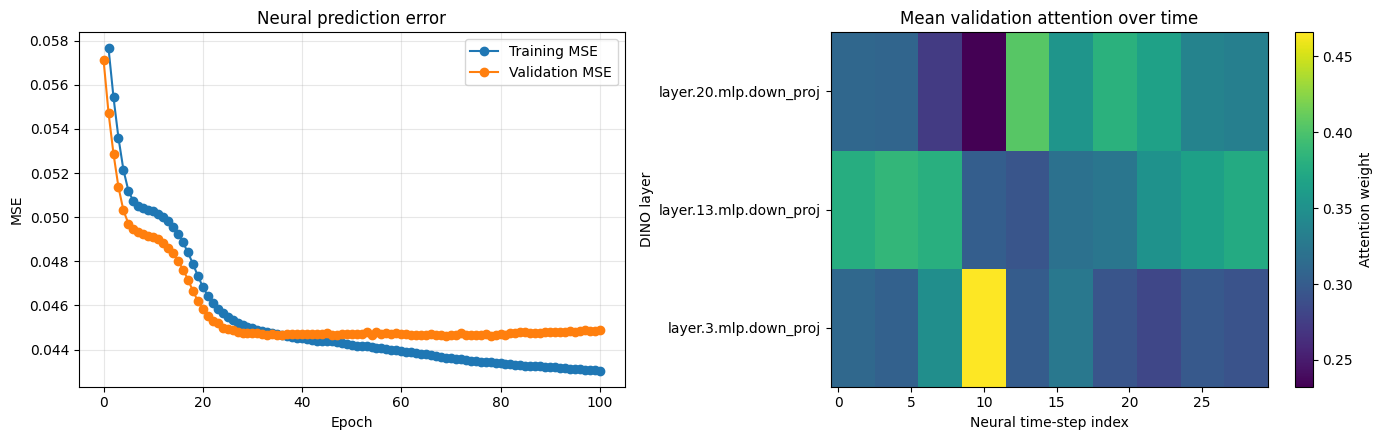

In [138]:
# Average attention over all validation stimuli after training.
m.eval()
validation_attention = []
with torch.no_grad():
    for inputs, _ in validation_loader:
        inputs = inputs.to(m.device)
        _, attention_weights = m(
            inputs,
            use_precomputed_features=use_precomputed_features,
        )
        validation_attention.append(attention_weights.cpu())
    # end for validation batch
# end with no gradient tracking

mean_coarse_attention = torch.cat(validation_attention, dim=0).mean(dim=0)

# Attention is constant inside each fine-time block produced by one coarse query.
mean_fine_attention = mean_coarse_attention.repeat_interleave(
    m.get_temporal_compression_ratio(),
    dim=0,
)

# Plot optimization error and the final validation-set attention schedule.
training_epochs = np.arange(1, len(training_losses) + 1)
validation_epochs = np.arange(0, len(validation_losses) + 1)
all_validation_losses = np.asarray(
    [initial_validation_loss, *validation_losses]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(
    training_epochs,
    training_losses,
    marker="o",
    label="Training MSE",
)
axes[0].plot(
    validation_epochs,
    all_validation_losses,
    marker="o",
    label="Validation MSE",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Neural prediction error")
axes[0].grid(alpha=0.3)
axes[0].legend()

attention_image = axes[1].imshow(
    mean_fine_attention.T.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
)
axes[1].set_xlabel("Neural time-step index")
axes[1].set_ylabel("DINO layer")
axes[1].set_title("Mean validation attention over time")
axes[1].set_yticks(np.arange(len(m.get_layer_names())))
axes[1].set_yticklabels(m.get_layer_names())
fig.colorbar(attention_image, ax=axes[1], label="Attention weight")
fig.tight_layout()
plt.show()
